In [1]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

In [22]:
from typing import TypedDict


class BatsmanState(TypedDict):

    runs:int
    balls:int
    fours:int
    sixes:int

    sr:float
    bp:float
    bpb:float
    summary:str

In [23]:
def calculate_sr(state:BatsmanState):
    print("anskn",state)
    sr = (state["runs"] / state["balls"]) * 100

    return {"sr": sr}

def calculate_bp(state:BatsmanState):
    bp = ( ((state["fours"] * 4) + (state["sixes"] * 6))/state["runs"]) * 100
    return {"bp": bp}

def calculate_bpb(state:BatsmanState):
    bpb = (state["balls"] / (state["fours"] + state["sixes"]))

    return {"bpb": bpb}

def summary(state:BatsmanState):
    summary = f"""
                Strike Rate - {state['sr']} \n
                Boundry Percentage - {state["bp"]} \n
                Balls Per Boundry - {state['bpb']} \n 
            """
    return {"summary":summary}


In [24]:
graph = StateGraph(BatsmanState)

graph.add_node("calculate_sr",calculate_sr)
graph.add_node("calculate_bp",calculate_bp)
graph.add_node("calculate_bpb",calculate_bpb)
graph.add_node("summary",summary)

graph.add_edge(START,"calculate_sr")
graph.add_edge(START,"calculate_bp")
graph.add_edge(START,"calculate_bpb")

graph.add_edge("calculate_sr","summary")
graph.add_edge("calculate_bp","summary")
graph.add_edge("calculate_bpb","summary")

graph.add_edge("summary",END)


graph = graph.compile()

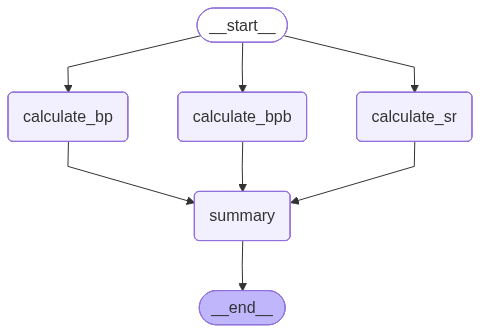

In [12]:
graph

In [25]:
initState = { 
    "runs":100,
    "balls":40,
    "fours":10,
    "sixes":5
}

res = graph.invoke(initState)

anskn {'runs': 100, 'balls': 40, 'fours': 10, 'sixes': 5}


In [30]:
res["summary"]

'\n                Strike Rate - 250.0 \n\n                Boundry Percentage - 70.0 \n\n                Balls Per Boundry - 2.6666666666666665 \n \n            '